In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from swmm_api import read_out_file
import os

E:\Anaconda\envs\drainage\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from matplotlib import rcParams

config = {
            "font.family": 'serif',
            "font.size": 22,
            "mathtext.fontset": 'stix',
            "font.serif": ['Times New Roman'],
            'axes.unicode_minus': False 
         }
rcParams.update(config)

In [3]:
train_rewards = {}
train_rewards['DRL-Base']=np.load('./Results_DQN_reward3/Results/Train.npy',allow_pickle=True).tolist()['Episode_reward'][:150]
train_rewards['DRL-GCI']=np.load('./Results_DQN_reward5/Results/Train_GI.npy',allow_pickle=True).tolist()['Episode_reward'][:150]
train_rewards['DRL-GIenv']=np.load('./Results_DQN_reward3_train_GI/Results/Train_GI.npy',allow_pickle=True).tolist()['Episode_reward'][:150]

# Normalized

In [4]:
# Min-Max normalization: (x - xmin) / (xmax - xmin)
def min_max_normalize(data):
    data = np.array(data)
    return (data - np.min(data)) / (np.max(data) - np.min(data))

In [5]:
norm_base = min_max_normalize(train_rewards['DRL-Base'])
norm_gienv = min_max_normalize(train_rewards['DRL-GIenv'])
norm_gci = min_max_normalize(train_rewards['DRL-GCI'])

Text(0.5, 0, 'Training Epoch')

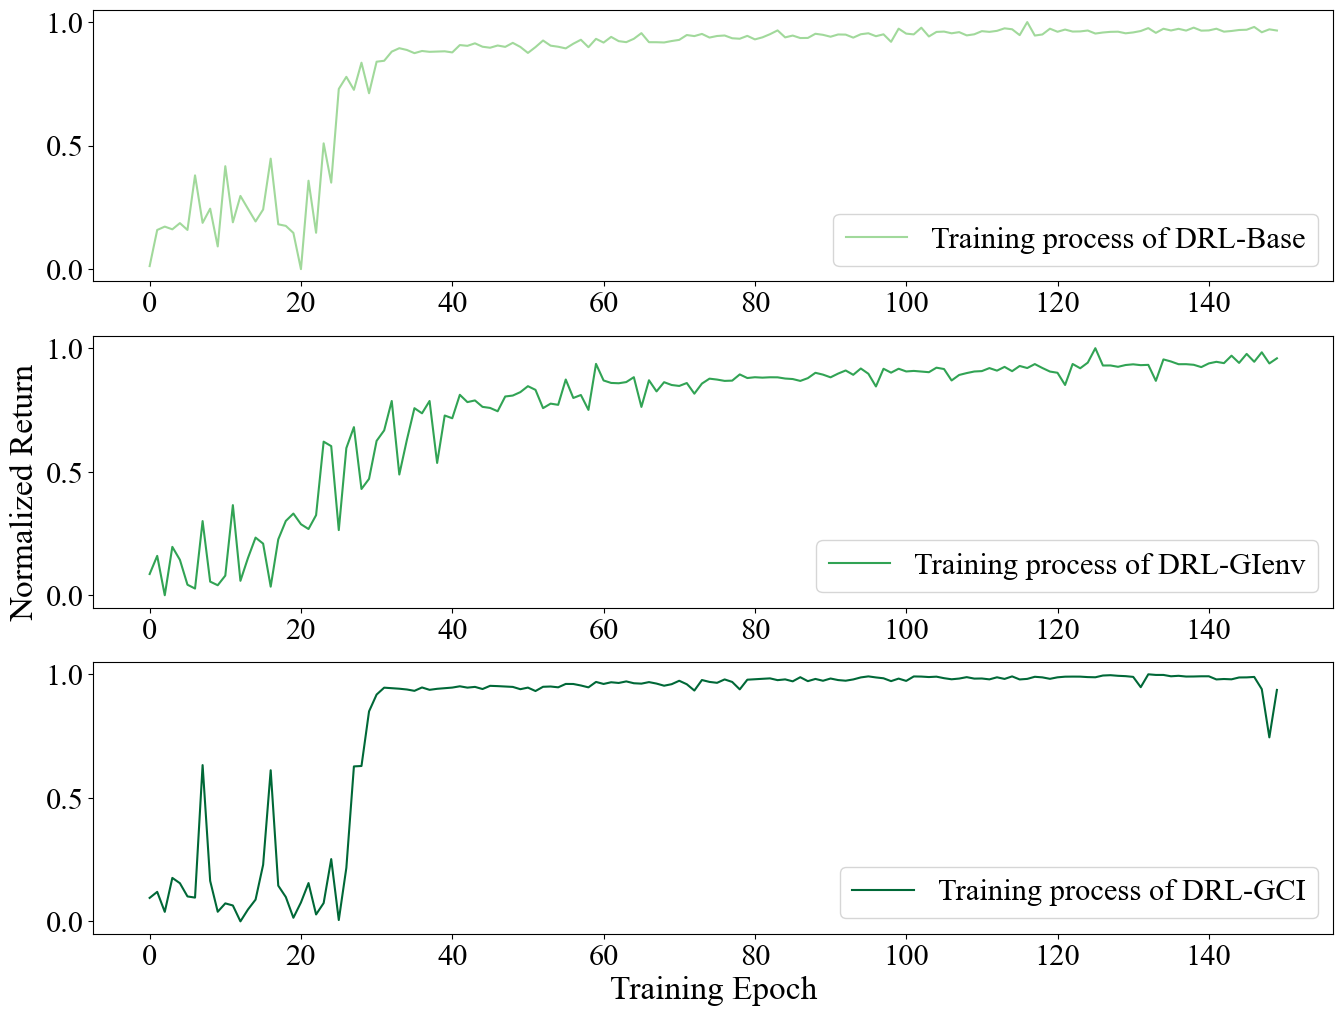

In [6]:
fig,ax = plt.subplots(3,1,figsize=(16,12))
ax[0].plot(norm_base, label='Training process of DRL-Base', color="#a1d99b")
ax[1].plot(norm_gienv, label='Training process of DRL-GIenv', color="#31a354")
ax[2].plot(norm_gci, label='Training process of DRL-GCI', color="#006837")

for i in range(3):
    ax[i].legend()

ax[1].set_ylabel('Normalized Return'+5*' ',fontsize=24)
ax[2].set_xlabel('Training Epoch',fontsize=24)

# plt.savefig('./DRL_train_all_normalized.png',dpi=200,bbox_inches='tight')